# Logistic Regression

In [11]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.formula.api import glm
from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA ,
QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [12]:
df = pd.read_csv('Smarket.csv')
df

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


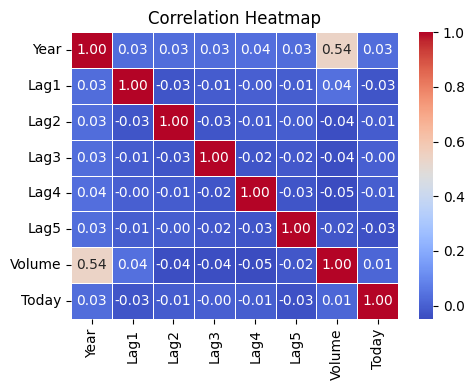

In [13]:
corr_matrix = df.select_dtypes(include=['number']).corr()

# 2. Create the figure and axis
fig, ax = plt.subplots(figsize=(5, 4))

# 3. Create the heatmap
sns.heatmap(corr_matrix, 
            annot=True,      # This puts the actual numbers inside the squares
            cmap='coolwarm', # The color scheme (red for positive, blue for negative)
            fmt='.2f',       # Limits the numbers to 2 decimal places
            linewidths=0.5,  # Adds a tiny gap between squares for readability
            ax=ax)           # Tells seaborn to draw on our 'ax' canvas

ax.set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()

<Axes: >

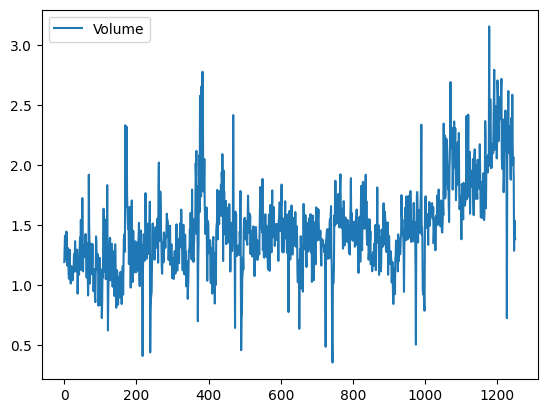

In [14]:
df.plot(y='Volume')

In [15]:
# Create a binary column: 1 if Up, 0 if Down
df['Direction_Bin'] = (df['Direction'] == 'Up').astype(int)

In [17]:
# Define the formula
formula = 'Direction_Bin ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume'

# Fit the GLM model
model_logit = glm(formula, data=df, family=sm.families.Binomial()).fit()

display(model_logit.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:          Direction_Bin   No. Observations:                 1250
Model:                            GLM   Df Residuals:                     1243
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -863.79
Date:                Mon, 06 Apr 2026   Deviance:                       1727.6
Time:                        15:09:14   Pearson chi2:                 1.25e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.002868
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1260      0.241     -0.523      0.601      -0.598       0.346
Lag1          -0.0731      0.050     -1.457      0.145      -0.171       0.025
Lag2          -0.0423      0.050     -0.845      0.398      -0.140       0.056
Lag3           0.0111      0.050      0.222      0.824      -0.087       0.109
Lag4           0.0094      0.050      0.187      0.851      -0.089       0.107
Lag5           0.0103      0.050      0.208      0.835      -0.087       0.107
Volume         0.1354      0.158      0.855      0.392      -0.175       0.446
==============================================================================
"""

In [20]:
# Predict the probability of 'Up' for the first 10 observations
probs = model_logit.predict(df.head(10))
display(probs)

# Convert probabilities to 'Up' or 'Down' labels using a 0.5 threshold
predictions = ["Up" if p > 0.5 else "Down" for p in probs]
display(predictions)

0    0.507084
1    0.481468
2    0.481139
3    0.515222
4    0.510781
5    0.506956
6    0.492651
7    0.509229
8    0.517614
9    0.488838
dtype: float64

['Up', 'Down', 'Down', 'Up', 'Up', 'Up', 'Down', 'Up', 'Up', 'Down']

### Logistic Regression on Smarket Data

#### 1. Key Mechanics
* **Link Function:** Logistic regression uses the **Logit** link function. It models the probability $P(Y=1)$ such that the output is always between 0 and 1.
* **Model Family:** In `statsmodels.api.glm`, we specify `family=sm.families.Binomial()`.

#### 2. Interpreting Coefficients
The coefficients ($\beta$) represent the change in **log-odds** for a one-unit increase in the predictor.
* To find the **Odds Ratio**, calculate $e^{\beta}$.
* If $e^{\beta} > 1$, the predictor increases the odds of the market going Up.
* If $e^{\beta} < 1$, the predictor decreases the odds of the market going Up.

#### 3. Prediction Logic
The model outputs a probability ($p$). A common threshold is **0.5**:
* If $p > 0.5 \rightarrow$ Predict **Up**
* If $p < 0.5 \rightarrow$ Predict **Down**

**Note:** In the `Smarket` dataset, you will likely find that the p-values for the Lags are quite high. This suggests that yesterday's market performance is a weak predictor of today's performance—which makes sense, as the stock market is notoriously difficult to predict!

## The Scikit-Learn Workflow
In Scikit-Learn, you follow a "Fit-Predict" pattern. Note that sklearn applies Regularization (L2) by default, which can make the coefficients slightly different from the statsmodels version. To match the book's logistic regression exactly, we set C=1e9 (which effectively turns regularization off).

In [23]:
from sklearn.linear_model import LogisticRegression

# 2. Define Features (X) and Target (y)
# Direction is the target; Lag1-Lag5 and Volume are features
X = df[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y = df['Direction'] # sklearn can handle 'Up'/'Down' strings directly as labels

# 3. Initialize and Fit the Model
# penalty=None or C=1e9 makes it a "pure" logistic regression
lr = LogisticRegression(C=1e9) 
lr.fit(X, y)

# 4. View Coefficients
# sklearn stores coefficients in .coef_ and intercept in .intercept_
coef_df = pd.DataFrame(lr.coef_, columns=X.columns, index=['Coefficient'])
display(f"Intercept: {lr.intercept_}")
display(coef_df)

'Intercept: [-0.12725676]'

,Lag1,Lag2,Lag3,Lag4,Lag5,Volume
Coefficient,-0.073381,-0.042529,0.011006,0.0093,0.010277,0.136154


In [24]:
# Get the first 5 predictions
print("Class Predictions:", lr.predict(X[:5]))

# Get probabilities for [Down, Up]
# The second column [:, 1] is usually the probability of 'Up'
probs = lr.predict_proba(X[:5])[:, 1]
print("Probabilities of 'Up':", probs)

Class Predictions: ['Up' 'Down' 'Down' 'Up' 'Up']
Probabilities of 'Up': [0.50698645 0.4813415  0.48096169 0.51510208 0.51063236]


### Logistic Regression with Scikit-Learn

#### 1. Implementation Steps
* **Step 1:** Isolate features (`X`) and the target (`y`).
* **Step 2:** Instantiate the `LogisticRegression()` class.
* **Step 3:** Use `.fit(X, y)` to train the model.

#### 2. Key Methods
* `lr.coef_`: Returns the weights assigned to each feature (Lags/Volume).
* `lr.predict(X)`: Returns the predicted class (e.g., "Up" or "Down").
* `lr.predict_proba(X)`: Returns the probability of each class.

#### 3. Pro-Tip: Matching ISLP Results
By default, `sklearn` uses **Penalty/Regularization** to prevent overfitting. To get the exact coefficients seen in the ISLP textbook (Table 4.1), you should use `LogisticRegression(penalty=None)` or set the inverse regularization strength `C` to a very high number like `1e9`.

## Predictions

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# 1. Load Data
df = pd.read_csv('Smarket.csv')

# 2. Split data based on Year (Temporal Split)
train = df[df['Year'] < 2005]
test = df[df['Year'] >= 2005]

# 3. Define X and y for both sets
X_train = train[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y_train = train['Direction']

X_test = test[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y_test = test['Direction']

# 4. Fit the Model (on training data ONLY)
lr = LogisticRegression(penalty=None)
lr.fit(X_train, y_train)

# 5. Predict on the Test Set
y_pred = lr.predict(X_test)

# 6. Evaluate
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred):.4f}")

Confusion Matrix:


array([[78, 33],
       [99, 42]])


Accuracy Score: 0.4762


### Logistic Regression: Training, Testing, and Evaluation

#### 1. Temporal Splitting
In financial data, we avoid `train_test_split(shuffle=True)`. Instead, we split by date to ensure the model does not "leak" future information into the past. 
* **Training Set:** 2001–2004 data.
* **Testing Set:** 2005 data.

#### 2. Key Evaluation Metrics
* **Accuracy:** The percentage of correct predictions. In the `Smarket` test set, a simple logistic model often achieves ~48%, which is slightly worse than random guessing.
* **Confusion Matrix:** Breaks down the specific types of errors (Type I vs Type II).

#### 3. Why the Model Might Fail
If the accuracy on the test set is much lower than the training set, the model has **overfit** the noise of the past. In the ISLP lab, the authors suggest that using fewer predictors (like just `Lag1` and `Lag2`) might actually improve test accuracy by reducing noise.

### Refining for Lag1 and Lag2 only

In [28]:
# 1. Load and Split (Temporal Split)
df = pd.read_csv('Smarket.csv')
train = df[df['Year'] < 2005]
test = df[df['Year'] >= 2005]

# 2. Refine Features: Use only Lag1 and Lag2
features = ['Lag1', 'Lag2']
X_train = train[features]
y_train = train['Direction']

X_test = test[features]
y_test = test['Direction']

# 3. Fit the Refined Model
lr_refined = LogisticRegression(penalty=None)
lr_refined.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = lr_refined.predict(X_test)

print("--- Refined Model Results (Lag1 & Lag2) ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred):.4f}")

# 5. Check a specific prediction (e.g., specific Lag values)
# Suppose Lag1 = 1.2 and Lag2 = 1.1
sample_move = pd.DataFrame([[1.2, 1.1]], columns=features)
print(f"\nPrediction for Lag1=1.2, Lag2=1.1: {lr_refined.predict(sample_move)[0]}")
print(f"Probability of Up: {lr_refined.predict_proba(sample_move)[0][1]:.4f}")

--- Refined Model Results (Lag1 & Lag2) ---
Confusion Matrix:
[[ 35  76]
 [ 35 106]]

Accuracy Score: 0.5595

Prediction for Lag1=1.2, Lag2=1.1: Down
Probability of Up: 0.4791
